In [3]:
# ============================
# Imports
# ============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================
# Load dataset
# ============================

DATA_PATH = "../Embeddings/siglip/final_dataset_strict_with_siglip.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head(2)

Dataset shape: (3060, 789)


,cat_no,titulo,autor,escuela_obra,tipo_objeto,datacion,tema,is_religious,is_fauna,century,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,P000002,El juicio de Paris,"Albani, Francesco",Italiana,Pintura,1650 - 1660,NaN,0,1,17th c.,...,-0.356265,3.988893,-0.038276,-0.140301,0.248423,-0.136362,-0.621971,-0.149800,0.343511,0.144266
1,P000006,Sagrada Familia y el cardenal Fernando de Medici,"Allori, Alessandro",Italiana,Pintura,1584,NaN,1,1,16th c.,...,0.258788,4.340028,-0.456233,0.113226,0.123200,-0.487182,-0.321165,-0.323432,0.417856,0.013111


In [5]:
# ============================
# Features & targets
# ============================

# Targets
y_warmth = df["dirmean_Warmth"]
y_competence = df["dirmean_Competence"]

# Embeddings
emb_cols = [col for col in df.columns if col.startswith("emb_")]
X = df[emb_cols]

print("X shape:", X.shape)

X shape: (3060, 768)


In [6]:
# ============================
# Train / test split
# ============================

X_train, X_test, y_w_train, y_w_test = train_test_split(
    X, y_warmth, test_size=0.2, random_state=42
)

_, _, y_c_train, y_c_test = train_test_split(
    X, y_competence, test_size=0.2, random_state=42
)

In [7]:
# ============================
# Scaling
# ============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# ============================
# Ridge regression
# ============================

model_w = Ridge(alpha=1.0)
model_c = Ridge(alpha=1.0)

model_w.fit(X_train_scaled, y_w_train)
model_c.fit(X_train_scaled, y_c_train)

# Predictions
y_w_pred = model_w.predict(X_test_scaled)
y_c_pred = model_c.predict(X_test_scaled)

In [9]:
# ============================
# Evaluation
# ============================

def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{name} R²: {r2:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print("-" * 30)

evaluate(y_w_test, y_w_pred, "Warmth")
evaluate(y_c_test, y_c_pred, "Competence")

Warmth R²: -0.2459
Warmth RMSE: 0.4718
------------------------------
Competence R²: -0.3140
Competence RMSE: 0.3013
------------------------------


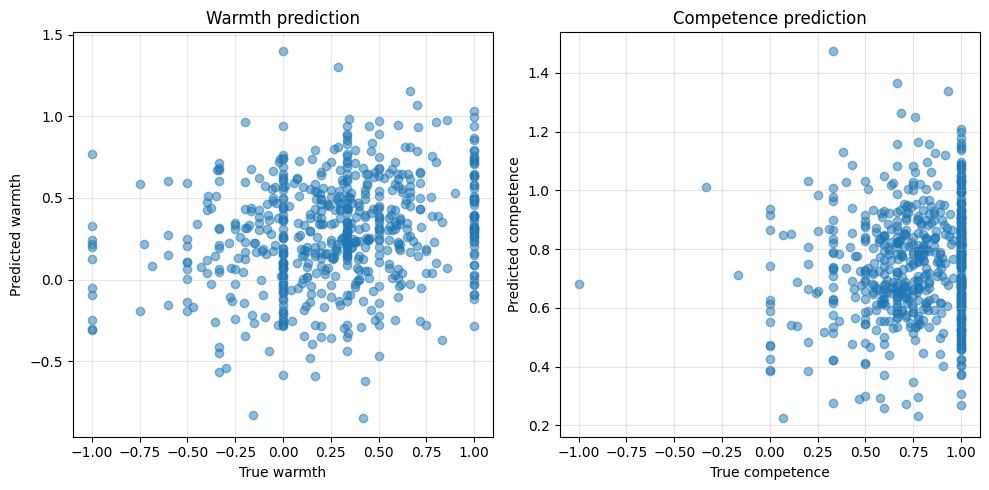

In [11]:
# ============================
# Predictions vs True
# ============================

plt.figure(figsize=(10, 5))

# Warmth
plt.subplot(1, 2, 1)
plt.scatter(y_w_test, y_w_pred, alpha=0.5)
plt.xlabel("True warmth")
plt.ylabel("Predicted warmth")
plt.title("Warmth prediction")
plt.grid(alpha=0.3)

# Competence
plt.subplot(1, 2, 2)
plt.scatter(y_c_test, y_c_pred, alpha=0.5)
plt.xlabel("True competence")
plt.ylabel("Predicted competence")
plt.title("Competence prediction")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ============================
# Mean baseline
# ============================

y_w_baseline = np.repeat(y_w_train.mean(), len(y_w_test))
y_c_baseline = np.repeat(y_c_train.mean(), len(y_c_test))

evaluate(y_w_test, y_w_baseline, "Warmth mean baseline")
evaluate(y_c_test, y_c_baseline, "Competence mean baseline")

Warmth mean baseline R²: -0.0015
Warmth mean baseline RMSE: 0.4230
------------------------------
Competence mean baseline R²: -0.0001
Competence mean baseline RMSE: 0.2629
------------------------------


In [13]:
# ============================
# Results summary table
# ============================

results_summary = pd.DataFrame([
    {
        "target": "Warmth",
        "model": "Mean baseline",
        "r2": r2_score(y_w_test, y_w_baseline),
        "rmse": np.sqrt(mean_squared_error(y_w_test, y_w_baseline))
    },
    {
        "target": "Warmth",
        "model": "Ridge",
        "r2": r2_score(y_w_test, y_w_pred),
        "rmse": np.sqrt(mean_squared_error(y_w_test, y_w_pred))
    },
    {
        "target": "Competence",
        "model": "Mean baseline",
        "r2": r2_score(y_c_test, y_c_baseline),
        "rmse": np.sqrt(mean_squared_error(y_c_test, y_c_baseline))
    },
    {
        "target": "Competence",
        "model": "Ridge",
        "r2": r2_score(y_c_test, y_c_pred),
        "rmse": np.sqrt(mean_squared_error(y_c_test, y_c_pred))
    }
])

results_summary

,target,model,r2,rmse
0,Warmth,Mean baseline,-0.001500,0.422981
1,Warmth,Ridge,-0.245914,0.471780
2,Competence,Mean baseline,-0.000110,0.262894
3,Competence,Ridge,-0.313968,0.301334


### Interpretation of baseline and Ridge results

The comparison between the mean baseline and Ridge regression provides important insight into the predictive value of the SigLIP embeddings.

For both warmth and competence, the mean baseline achieves R² values close to zero, which is expected, as it simply predicts the average target value from the training set. This serves as a minimal benchmark for model performance.

However, the Ridge regression model performs substantially worse than this baseline, with clearly negative R² values for both targets (−0.25 for warmth and −0.31 for competence). This indicates that the linear model is not only failing to capture meaningful relationships, but is actively introducing noise compared to a constant predictor.

These results suggest that:
- The relationship between visual embeddings and the SADCAT-derived targets is not linearly recoverable
- The competence dimension is particularly difficult to predict, likely due to the strong ceiling effect observed in the target distribution
- Even for warmth, which showed greater variability in the exploratory analysis, the signal is too weak or too complex for a simple linear model to exploit

Overall, this experiment indicates that either:
1. The embeddings do not encode stereotype-relevant information in a directly usable way, or  
2. The signal is present but requires more flexible, non-linear models to be extracted  

This motivates the next step of the analysis, where non-linear models are introduced to test whether predictive performance can be improved.

## 4. Testing a non-linear model: Random Forest

The negative Ridge results suggest that a simple linear mapping is not sufficient to recover warmth and competence from the SigLIP embeddings. To test whether the signal may still be present in a more complex form, a non-linear Random Forest regressor is trained on the same embedding features.

This step helps determine whether the problem lies in the absence of useful information in the embeddings, or in the inability of a linear model to capture more complex relationships.

In [14]:
# ============================
# Random Forest
# ============================

from sklearn.ensemble import RandomForestRegressor

rf_w = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_c = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
rf_w.fit(X_train, y_w_train)
rf_c.fit(X_train, y_c_train)

# Predict
y_w_pred_rf = rf_w.predict(X_test)
y_c_pred_rf = rf_c.predict(X_test)

In [15]:
# ============================
# RF Evaluation
# ============================

evaluate(y_w_test, y_w_pred_rf, "Warmth RF")
evaluate(y_c_test, y_c_pred_rf, "Competence RF")

Warmth RF R²: 0.1118
Warmth RF RMSE: 0.3983
------------------------------
Competence RF R²: -0.0437
Competence RF RMSE: 0.2686
------------------------------


In [16]:
# ============================
# Results summary table (updated)
# ============================

results_summary = pd.DataFrame([
    {
        "target": "Warmth",
        "model": "Mean baseline",
        "r2": r2_score(y_w_test, y_w_baseline),
        "rmse": np.sqrt(mean_squared_error(y_w_test, y_w_baseline))
    },
    {
        "target": "Warmth",
        "model": "Ridge",
        "r2": r2_score(y_w_test, y_w_pred),
        "rmse": np.sqrt(mean_squared_error(y_w_test, y_w_pred))
    },
    {
        "target": "Warmth",
        "model": "Random Forest",
        "r2": r2_score(y_w_test, y_w_pred_rf),
        "rmse": np.sqrt(mean_squared_error(y_w_test, y_w_pred_rf))
    },
    {
        "target": "Competence",
        "model": "Mean baseline",
        "r2": r2_score(y_c_test, y_c_baseline),
        "rmse": np.sqrt(mean_squared_error(y_c_test, y_c_baseline))
    },
    {
        "target": "Competence",
        "model": "Ridge",
        "r2": r2_score(y_c_test, y_c_pred),
        "rmse": np.sqrt(mean_squared_error(y_c_test, y_c_pred))
    },
    {
        "target": "Competence",
        "model": "Random Forest",
        "r2": r2_score(y_c_test, y_c_pred_rf),
        "rmse": np.sqrt(mean_squared_error(y_c_test, y_c_pred_rf))
    }
])

results_summary

,target,model,r2,rmse
0,Warmth,Mean baseline,-0.001500,0.422981
1,Warmth,Ridge,-0.245914,0.471780
2,Warmth,Random Forest,0.111753,0.398348
3,Competence,Mean baseline,-0.000110,0.262894
4,Competence,Ridge,-0.313968,0.301334
5,Competence,Random Forest,-0.043721,0.268564


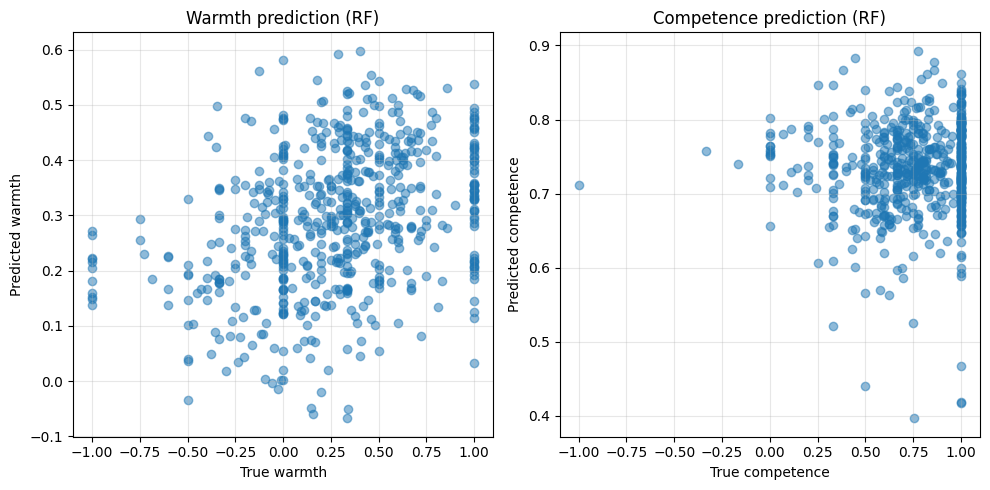

In [18]:
# ============================
# RF Predictions vs True
# ============================

plt.figure(figsize=(10, 5))

# Warmth
plt.subplot(1, 2, 1)
plt.scatter(y_w_test, y_w_pred_rf, alpha=0.5)
plt.xlabel("True warmth")
plt.ylabel("Predicted warmth")
plt.title("Warmth prediction (RF)")
plt.grid(alpha=0.3)

# Competence
plt.subplot(1, 2, 2)
plt.scatter(y_c_test, y_c_pred_rf, alpha=0.5)
plt.xlabel("True competence")
plt.ylabel("Predicted competence")
plt.title("Competence prediction (RF)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Random Forest results

The introduction of a non-linear Random Forest model leads to a clear improvement in predictive performance for the warmth dimension. While the linear Ridge model produced strongly negative R² values, the Random Forest achieves a positive R² (≈ 0.11), indicating that the embeddings do contain usable information about warmth, but that this information is not linearly separable.

This suggests that stereotype-related visual signals are encoded in a complex way within the embedding space, requiring non-linear models to be extracted effectively.

In contrast, the competence dimension remains difficult to predict. Although the Random Forest slightly improves over Ridge, performance remains close to the baseline. This confirms the observations from the exploratory analysis: competence scores are highly skewed toward the upper bound, creating a strong ceiling effect and limiting the variability that models can learn from.

Overall, these results indicate that:
- Visual embeddings contain meaningful signal for warmth, but require non-linear modeling
- Competence is substantially harder to recover, likely due to both data imbalance and limited informative variation
- The predictive capacity of embeddings is strongly dependent on the structure of the target variable